<div class="alert alert-warning">

# Demo — The DDM as a Decision Policy in Value-Based Choice

In reinforcement learning and decision neuroscience, agents are often modelled as choosing between options using a **softmax policy**:

$$P(A) = \frac{1}{1 + e^{-\beta \Delta V}}$$

where $\Delta V = V_A - V_B$ is the value difference and $\beta$ (inverse temperature) controls how sensitive choices are to value.

But where does this formula come from neurally? The **Drift Diffusion Model (DDM)** gives a mechanistic account: evidence (proportional to $\Delta V$) accumulates noisily until it crosses a decision threshold. This demo shows that:

1. **P(A):** The DDM produces a sigmoid choice function — identical to the softmax — with $\beta = 2a\alpha / \sigma^2$
2. **RT:** The DDM additionally predicts that choices near $\Delta V = 0$ (ambiguous) are slower, while high-$|\Delta V|$ choices are fast — a pattern absent from the softmax
3. **Fitting:** Fitting a softmax to DDM-simulated choices recovers $\beta$ accurately, and the fitted $\beta$ tracks the DDM's signal-to-noise ratio

</div>

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

---
## 1. The Model

In the DDM for value-based choice, the decision variable $x(t)$ starts at zero and evolves as:

$$x(t + dt) = x(t) + \underbrace{\alpha \cdot \Delta V}_{\text{drift}} \cdot dt + \underbrace{\sigma \cdot \sqrt{dt} \cdot \varepsilon_t}_{\text{noise}}$$

A decision is made as soon as $x$ hits $+a$ (choose A) or $-a$ (choose B).

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Value difference | $\Delta V = V_A - V_B$ | How much better A is than B |
| Drift scaling | $\alpha$ | How strongly value translates to drift |
| Boundary | $a$ | How much evidence is required before deciding |
| Noise | $\sigma$ | Trial-by-trial fluctuations in the accumulation |
| Non-decision time | $T_{nd}$ | Sensory + motor delay added to every RT |

In [2]:
# Default DDM parameters
A     = 1.0    # boundary
ALPHA = 1.0    # drift scaling
SIGMA = 1.0    # noise
T_ND  = 0.3    # non-decision time [s]
DT    = 0.002  # time step [s]


def simulate_ddm(delta_v, n_trials=1000, a=A, alpha=ALPHA, sigma=SIGMA,
                 t_nd=T_ND, dt=DT, max_time=5.0, seed=None):
    """
    Simulate the DDM for a given value difference.
    Returns choices (1=A, 0=B) and reaction times [s].
    """
    if seed is not None:
        np.random.seed(seed)

    mu = alpha * delta_v
    n_steps = int(max_time / dt)

    # Generate all trajectories at once: (n_trials, n_steps)
    noise = sigma * np.sqrt(dt) * np.random.randn(n_trials, n_steps)
    x = np.cumsum(mu * dt + noise, axis=1)

    upper = x >= a
    lower = x <= -a

    # First crossing index (inf if never crossed within max_time)
    def first_hit(mask):
        has = mask.any(axis=1)
        idx = np.where(has, np.argmax(mask, axis=1), n_steps).astype(float)
        idx[~has] = np.inf
        return idx

    t_upper = first_hit(upper)
    t_lower = first_hit(lower)

    upper_wins = t_upper <= t_lower
    choices = upper_wins.astype(float)

    # Trials that never cross: assign by final position
    no_cross = np.isinf(t_upper) & np.isinf(t_lower)
    choices[no_cross] = (x[no_cross, -1] > 0).astype(float)

    t_decision = np.minimum(t_upper, t_lower)
    t_decision[np.isinf(t_decision)] = n_steps - 1
    rts = (t_decision + 1) * dt + t_nd

    return choices, rts

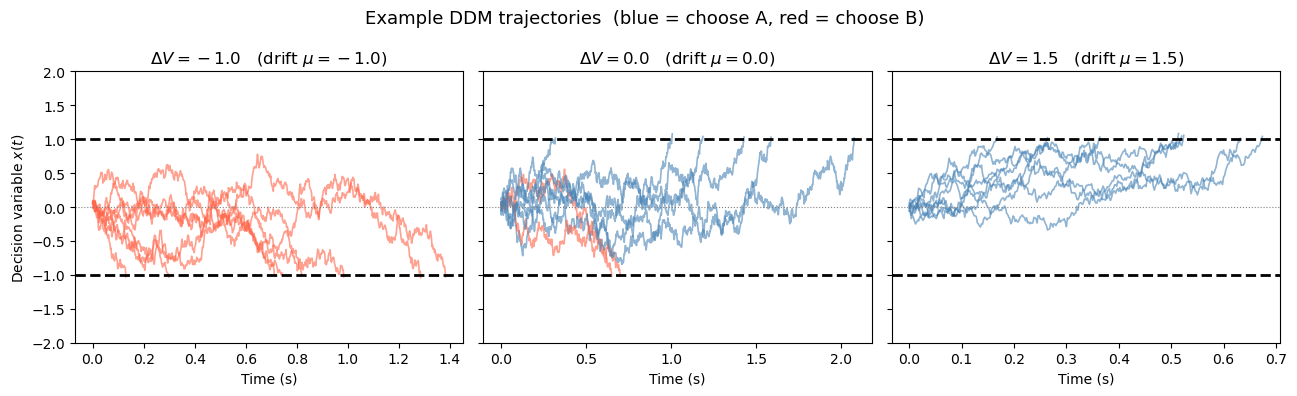

In [3]:
# Show a few example trajectories for different value differences
np.random.seed(0)
n_steps_show = int(3.0 / DT)
t_show = np.arange(n_steps_show) * DT

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, dv in zip(axes, [-1.0, 0.0, 1.5]):
    mu = ALPHA * dv
    for _ in range(8):
        noise = SIGMA * np.sqrt(DT) * np.random.randn(n_steps_show)
        x = np.cumsum(mu * DT + noise)
        # Clip at first boundary crossing
        hit = np.where((x >= A) | (x <= -A))[0]
        end = hit[0] + 1 if len(hit) else n_steps_show
        color = 'steelblue' if x[end-1] >= 0 else 'tomato'
        ax.plot(t_show[:end], x[:end], color=color, alpha=0.6, linewidth=1.2)
    ax.axhline( A, color='k', linewidth=2, linestyle='--')
    ax.axhline(-A, color='k', linewidth=2, linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Time (s)')
    ax.set_title(f'$\\Delta V = {dv}$   (drift $\\mu = {mu}$)')
    ax.set_ylim([-2, 2])

axes[0].set_ylabel('Decision variable $x(t)$')
fig.suptitle('Example DDM trajectories  (blue = choose A, red = choose B)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Plot A — P(choose A) as a function of $\Delta V$

The DDM has a known analytic solution for choice probability. For drift $\mu = \alpha \cdot \Delta V$, boundary $a$, and noise $\sigma$:

$$P(A) = \frac{1}{1 + e^{-2a\mu / \sigma^2}} = \sigma\!\left(\beta \cdot \Delta V\right), \qquad \beta = \frac{2 a \alpha}{\sigma^2}$$

This is **exactly the softmax** — with $\beta$ determined by the DDM's signal-to-noise ratio.

In [4]:
# Run simulations over a range of delta_V values
delta_vs = np.linspace(-3, 3, 25)
n_trials  = 1000

p_A     = np.zeros(len(delta_vs))
mean_rt = np.zeros(len(delta_vs))
all_choices, all_dvs = [], []

for i, dv in enumerate(delta_vs):
    choices, rts = simulate_ddm(dv, n_trials=n_trials, seed=i)
    p_A[i]     = choices.mean()
    mean_rt[i] = rts.mean()
    all_choices.append(choices)
    all_dvs.append(np.full(n_trials, dv))

all_choices = np.concatenate(all_choices)
all_dvs     = np.concatenate(all_dvs)

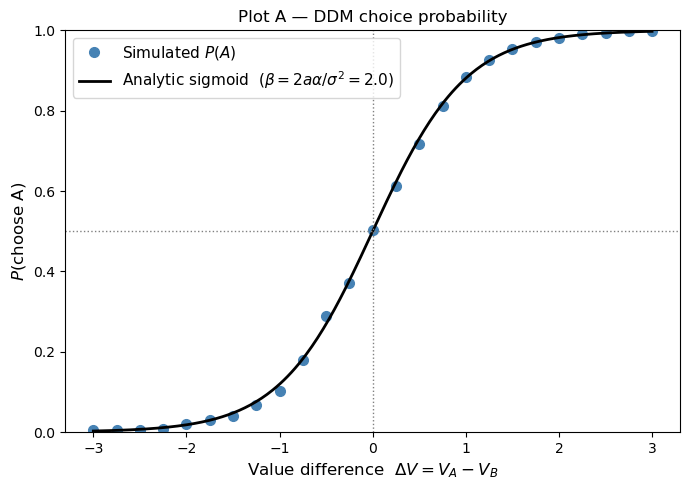

Theoretical beta = 2 * a * alpha / sigma^2 = 2.00


In [5]:
# Analytic prediction
beta_theory = 2 * A * ALPHA / SIGMA**2
dv_fine = np.linspace(-3, 3, 300)
p_analytic = 1 / (1 + np.exp(-beta_theory * dv_fine))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(delta_vs, p_A, 'o', color='steelblue', markersize=7,
        label='Simulated $P(A)$')
ax.plot(dv_fine, p_analytic, 'k-', linewidth=2,
        label=f'Analytic sigmoid  ($\\beta = 2a\\alpha/\\sigma^2 = {beta_theory:.1f}$)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.axvline(0,   color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Value difference  $\\Delta V = V_A - V_B$', fontsize=12)
ax.set_ylabel('$P$(choose A)', fontsize=12)
ax.set_title('Plot A — DDM choice probability')
ax.legend(fontsize=11)
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print(f'Theoretical beta = 2 * a * alpha / sigma^2 = {beta_theory:.2f}')

**The simulated P(A) follows the sigmoid exactly.** The slope is determined entirely by $\beta = 2a\alpha/\sigma^2$: a steeper sigmoid means faster, more value-sensitive decisions.

---
## 3. Plot B — Reaction Time as a function of $\Delta V$

Unlike the softmax, the DDM also predicts **reaction times**. When $\Delta V \approx 0$, the drift is near zero and the accumulator wanders for a long time before reaching a boundary. When $|\Delta V|$ is large, the strong drift pushes the accumulator quickly to the correct boundary.

This produces a **U-shaped RT function**: slowest at ambiguity, fastest for easy choices.

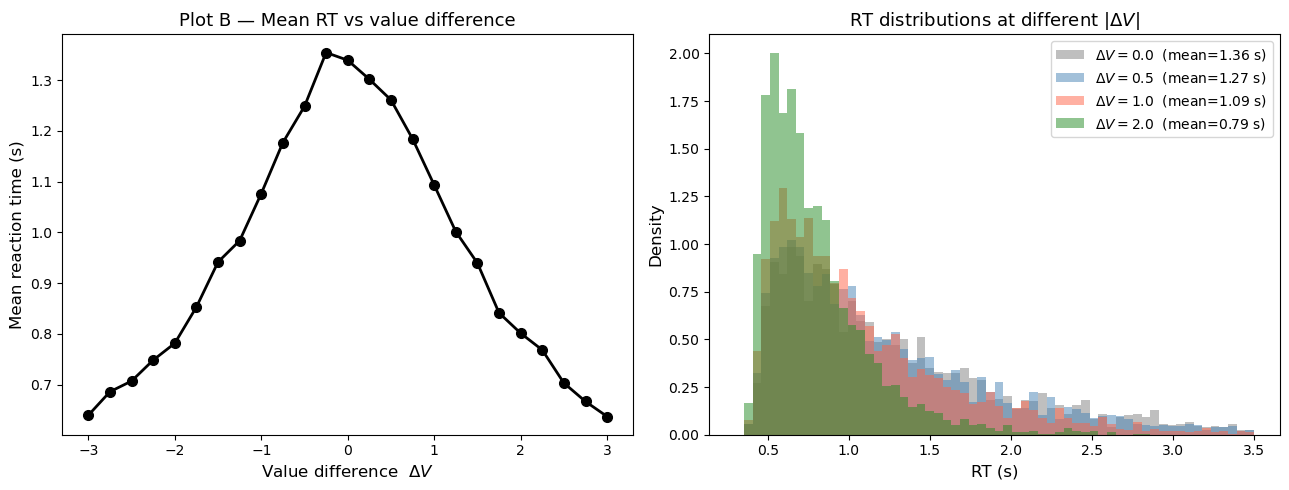

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: mean RT vs ΔV ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(delta_vs, mean_rt, 'ko-', linewidth=2, markersize=7)
ax.set_xlabel('Value difference  $\\Delta V$', fontsize=12)
ax.set_ylabel('Mean reaction time (s)', fontsize=12)
ax.set_title('Plot B — Mean RT vs value difference', fontsize=13)

# ── Right: RT distributions at several ΔV values ─────────────────────────────
ax = axes[1]
dv_show  = [0.0, 0.5, 1.0, 2.0]
colors   = ['gray', 'steelblue', 'tomato', 'forestgreen']
for dv, col in zip(dv_show, colors):
    _, rts = simulate_ddm(dv, n_trials=3000, seed=77)
    ax.hist(rts, bins=60, range=(0.3, 3.5), density=True,
            alpha=0.5, color=col, label=f'$\\Delta V = {dv}$  (mean={rts.mean():.2f} s)')
ax.set_xlabel('RT (s)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('RT distributions at different $|\\Delta V|$', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

**Key observations:**

- **Mean RT is U-shaped** in $\Delta V$: slowest when the two options are equally attractive ($\Delta V \approx 0$), fastest when the difference is large.
- **RT distributions shift and compress** as $|\Delta V|$ increases: at $\Delta V = 0$ the distribution is wide and slow (pure noise, long tail); at $\Delta V = 2$ it is narrow and fast (strong drift resolves quickly).

**Note on correct vs error RTs:** In this pure DDM (constant drift, starting point $x = 0$), it can be shown mathematically that $\mathbb{E}[\text{RT} | \text{correct}] \approx \mathbb{E}[\text{RT} | \text{error}]$ — the conditional means are nearly identical. Correct/error RT differences require **across-trial variability in drift** (as in the full Ratcliff model), which adds realism but also more parameters. For this demo, the key RT prediction is the U-shaped mean and the shift in the full distribution.

The softmax produces the **same choice probabilities** but is completely silent on RTs — it has no mechanism that produces any timing prediction.

---
## 4. Plot C — Fitting a Softmax to DDM Choices

Suppose we only observed the *choices* (not the RTs). We could fit a softmax model to those choices. What value of $\beta$ would we recover, and what does it tell us about the underlying DDM?

In [7]:
def fit_softmax(delta_vs_flat, choices_flat):
    """Fit beta via maximum likelihood of softmax model P(A) = sigmoid(beta * dv)."""
    def neg_ll(beta):
        p = 1 / (1 + np.exp(-beta * delta_vs_flat))
        p = np.clip(p, 1e-8, 1 - 1e-8)
        return -np.sum(choices_flat * np.log(p) + (1 - choices_flat) * np.log(1 - p))
    result = minimize_scalar(neg_ll, bounds=(0.01, 20.0), method='bounded')
    return result.x


beta_fit = fit_softmax(all_dvs, all_choices)
print(f'Fitted softmax beta:     {beta_fit:.3f}')
print(f'Theoretical DDM beta:    {beta_theory:.3f}  (= 2 * a * alpha / sigma^2)')
print(f'Relative error: {abs(beta_fit - beta_theory)/beta_theory * 100:.1f}%')

Fitted softmax beta:     2.026
Theoretical DDM beta:    2.000  (= 2 * a * alpha / sigma^2)
Relative error: 1.3%


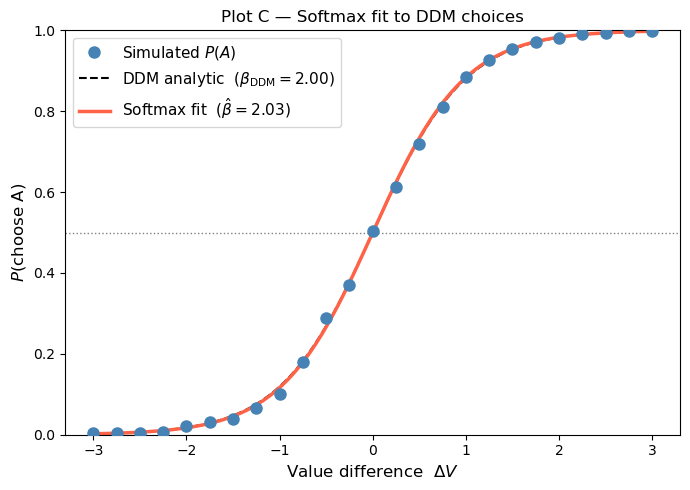

In [8]:
# Overlay the fitted softmax on the simulated P(A)
p_fit = 1 / (1 + np.exp(-beta_fit * dv_fine))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(delta_vs, p_A, 'o', color='steelblue', markersize=8, label='Simulated $P(A)$', zorder=3)
ax.plot(dv_fine, p_analytic, 'k--', linewidth=1.5,
        label=f'DDM analytic  ($\\beta_{{\\rm DDM}} = {beta_theory:.2f}$)')
ax.plot(dv_fine, p_fit, 'tomato', linewidth=2.5,
        label=f'Softmax fit  ($\\hat{{\\beta}} = {beta_fit:.2f}$)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Value difference  $\\Delta V$', fontsize=12)
ax.set_ylabel('$P$(choose A)', fontsize=12)
ax.set_title('Plot C — Softmax fit to DDM choices')
ax.legend(fontsize=11)
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

The fitted softmax recovers the correct $\beta$ — because the two models are **mathematically equivalent for choices alone**.

---
## 5. What does $\beta$ mean in terms of DDM parameters?

We fix $\sigma = 1$ throughout. Since $\beta = 2a\alpha / \sigma^2 = 2a\alpha$, two parameters remain free: the boundary $a$ and the drift scaling $\alpha$. Let's vary each independently to see how they affect the choice curve.

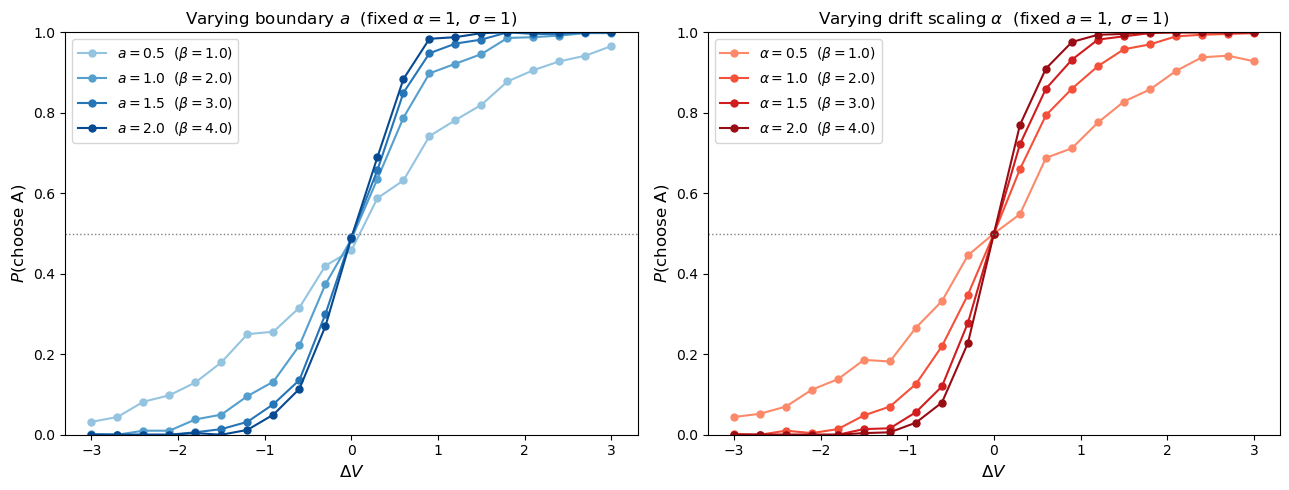

In [9]:
# Vary boundary a and drift scaling alpha (sigma fixed at 1)
a_values     = [0.5, 1.0, 1.5, 2.0]
alpha_values = [0.5, 1.0, 1.5, 2.0]
delta_vs_fine = np.linspace(-3, 3, 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Vary a, fix alpha=1, sigma=1 ---
ax = axes[0]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(a_values)))
for a_val, col in zip(a_values, colors):
    p = []
    for dv in delta_vs_fine:
        ch, _ = simulate_ddm(dv, n_trials=500, a=a_val, alpha=ALPHA, sigma=SIGMA, seed=int(dv*10+100))
        p.append(ch.mean())
    beta_th = 2 * a_val * ALPHA / SIGMA**2
    ax.plot(delta_vs_fine, p, 'o-', color=col, markersize=5, linewidth=1.5,
            label=f'$a = {a_val}$  ($\\beta = {beta_th:.1f}$)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('$\\Delta V$', fontsize=12)
ax.set_ylabel('$P$(choose A)', fontsize=12)
ax.set_title('Varying boundary $a$  (fixed $\\alpha=1,\\ \\sigma=1$)')
ax.legend(fontsize=10)
ax.set_ylim([0, 1])

# --- Vary alpha, fix a=1, sigma=1 ---
ax = axes[1]
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(alpha_values)))
for al_val, col in zip(alpha_values, colors):
    p = []
    for dv in delta_vs_fine:
        ch, _ = simulate_ddm(dv, n_trials=500, a=A, alpha=al_val, sigma=SIGMA, seed=int(dv*10+200))
        p.append(ch.mean())
    beta_th = 2 * A * al_val / SIGMA**2
    ax.plot(delta_vs_fine, p, 'o-', color=col, markersize=5, linewidth=1.5,
            label=f'$\\alpha = {al_val}$  ($\\beta = {beta_th:.1f}$)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('$\\Delta V$', fontsize=12)
ax.set_ylabel('$P$(choose A)', fontsize=12)
ax.set_title('Varying drift scaling $\\alpha$  (fixed $a=1,\\ \\sigma=1$)')
ax.legend(fontsize=10)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

**Interpreting $\beta = 2a\alpha$** (with $\sigma = 1$ fixed):

| $\beta$ large | $\beta$ small |
|:---|:---|
| High boundary $a$ → cautious, requires more evidence before deciding | Low boundary $a$ → impulsive, decides on little evidence |
| High drift scaling $\alpha$ → value differences translate strongly to drift | Low $\alpha$ → weak coupling between value and accumulation |

**Both $a$ and $\alpha$ produce identical choice curves for the same $\beta$** — but they make different RT predictions. A high-$a$ agent accumulates slowly and decides late; a high-$\alpha$ agent accumulates fast and also decides early. RT data is needed to tell them apart.

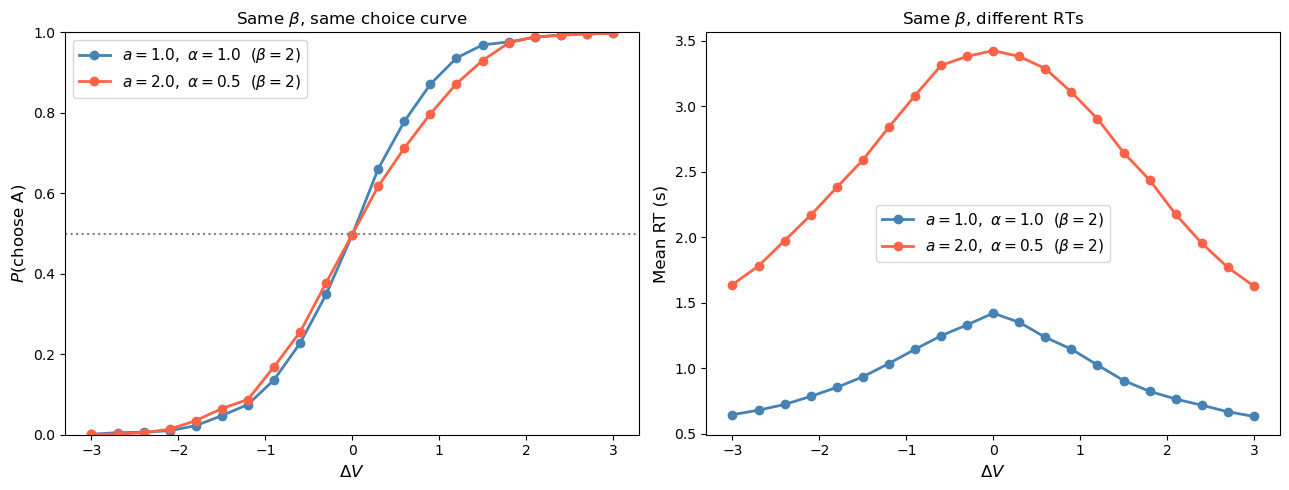

In [10]:
# Two parameter sets with the same beta but different RTs (sigma fixed at 1)
# beta = 2 * a * alpha / sigma^2 = 2 * a * alpha
# Set 1: a=1, alpha=1  → beta=2  (moderate boundary, moderate value sensitivity)
# Set 2: a=2, alpha=0.5 → beta=2  (high boundary, low value sensitivity)
configs = [
    dict(a=1.0, alpha=1.0,  label='$a=1.0,\\ \\alpha=1.0$  ($\\beta=2$)'),
    dict(a=2.0, alpha=0.5,  label='$a=2.0,\\ \\alpha=0.5$  ($\\beta=2$)'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# P(A) — should be identical
ax = axes[0]
for cfg, col in zip(configs, ['steelblue', 'tomato']):
    p = [simulate_ddm(dv, n_trials=800, a=cfg['a'], alpha=cfg['alpha'],
                      sigma=SIGMA, seed=42)[0].mean()
         for dv in delta_vs_fine]
    ax.plot(delta_vs_fine, p, 'o-', color=col, linewidth=2, markersize=6, label=cfg['label'])
ax.axhline(0.5, color='gray', linestyle=':')
ax.set_xlabel('$\\Delta V$', fontsize=12)
ax.set_ylabel('$P$(choose A)', fontsize=12)
ax.set_title('Same $\\beta$, same choice curve')
ax.legend(fontsize=11)
ax.set_ylim([0, 1])

# Mean RT — should differ
ax = axes[1]
for cfg, col in zip(configs, ['steelblue', 'tomato']):
    rts = [simulate_ddm(dv, n_trials=800, a=cfg['a'], alpha=cfg['alpha'],
                        sigma=SIGMA, seed=42)[1].mean()
           for dv in delta_vs_fine]
    ax.plot(delta_vs_fine, rts, 'o-', color=col, linewidth=2, markersize=6, label=cfg['label'])
ax.set_xlabel('$\\Delta V$', fontsize=12)
ax.set_ylabel('Mean RT (s)', fontsize=12)
ax.set_title('Same $\\beta$, different RTs')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## Summary

| | Softmax | DDM |
|---|---|---|
| **Predicts P(choice)** | ✓ sigmoid in $\Delta V$ | ✓ same sigmoid, $\beta = 2a\alpha$ (with $\sigma=1$) |
| **Predicts RT** | ✗ | ✓ U-shaped in $\Delta V$ |
| **Separates** $a$ and $\alpha$ | ✗ (only their product) | ✓ (via RT) |
| **Mechanistic** | ✗ (policy only) | ✓ (accumulation process) |

**Key takeaway:** With $\sigma$ fixed, the softmax $\beta = 2a\alpha$ combines two distinct cognitive quantities: the evidence threshold $a$ (how cautious the agent is) and the drift scaling $\alpha$ (how strongly value differences drive the decision). Both produce identical choice curves when their product is the same — but they predict different RTs. A high-$a$ agent is slow and cautious; a high-$\alpha$ agent is fast and value-sensitive. Only RT data disambiguates them.

---
## 6. The Race Model

The DDM tracks the *difference* between two accumulators — it is inherently a two-option model. The **race model** (also called the "horse race" or "accumulator race") takes a different approach: each option gets its **own independent accumulator**, starting at zero, drifting upward in proportion to its value. The first to cross threshold wins.

For option $k$ with value $V_k$:

$$x_k(t + dt) = x_k(t) + \alpha V_k \cdot dt + \sigma\sqrt{dt}\;\varepsilon_t^{(k)}$$

A choice is made the moment any accumulator first hits $+a$. The parameters $\alpha$, $\sigma$, $a$, $T_{nd}$ play the same roles as in the DDM.

**Key differences from the DDM:**

| | DDM | Race |
|---|---|---|
| Number of options | 2 only | Any $K$ |
| Accumulates | *Difference* of evidence | Each option separately |
| Noise on difference | $\sigma$ | $\sigma\sqrt{2}$ (independent accumulators) |
| Effective $\beta$ | $2a\alpha/\sigma^2$ | $\approx a\alpha/\sigma^2$ |

Because each accumulator has independent noise, the effective noise on the *difference* is $\sigma\sqrt{2}$, giving an effective $\beta$ roughly half that of the DDM with the same parameters. The shape of the choice and RT functions is otherwise very similar.

In [11]:
BASELINE = 1.0   # value offset — ensures positive drift even for the "worse" option


def simulate_race(values, n_trials=1000, alpha=ALPHA, sigma=SIGMA,
                  a=A, t_nd=T_ND, dt=DT, max_time=5.0, seed=None):
    """
    Simple race model: K independent noisy accumulators.

    Parameters
    ----------
    values : array-like, shape (K,) — subjective value of each option.
             Values should be positive so accumulators drift upward on average.

    Returns
    -------
    choices : (n_trials,)  int   — index 0..K-1 of the winning option
    rts     : (n_trials,)  float — reaction times [s]
    """
    if seed is not None:
        np.random.seed(seed)

    values  = np.asarray(values, float)
    K       = len(values)
    mu      = alpha * values           # drift rates, shape (K,)
    n_steps = int(max_time / dt)

    # Trajectories: (n_trials, K, n_steps)
    noise = sigma * np.sqrt(dt) * np.random.randn(n_trials, K, n_steps)
    x     = np.cumsum(mu[None, :, None] * dt + noise, axis=2)

    # First crossing time for each accumulator (inf if never crossed)
    hit     = x >= a                   # bool (n_trials, K, n_steps)
    t_cross = np.full((n_trials, K), np.inf)
    for k in range(K):
        has_k        = hit[:, k, :].any(axis=1)
        idx_k        = np.argmax(hit[:, k, :], axis=1).astype(float)
        idx_k[~has_k] = np.inf
        t_cross[:, k] = idx_k

    # Winner = earliest crossing
    choices = np.argmin(t_cross, axis=1)
    t_win   = t_cross[np.arange(n_trials), choices]

    # Trials where no accumulator crossed — assign by final position
    no_cross = np.isinf(t_win)
    if no_cross.any():
        choices[no_cross] = np.argmax(x[no_cross, :, -1], axis=1)
        t_win[no_cross]   = n_steps - 1

    rts = (t_win + 1) * dt + t_nd
    return choices, rts

### 6.1 — Two choices: DDM vs Race model

To compare fairly, we keep $\Delta V = V_A - V_B$ fixed and set $V_A = \text{BASELINE} + \Delta V/2$, $V_B = \text{BASELINE} - \Delta V/2$, so the absolute level is the same across conditions.

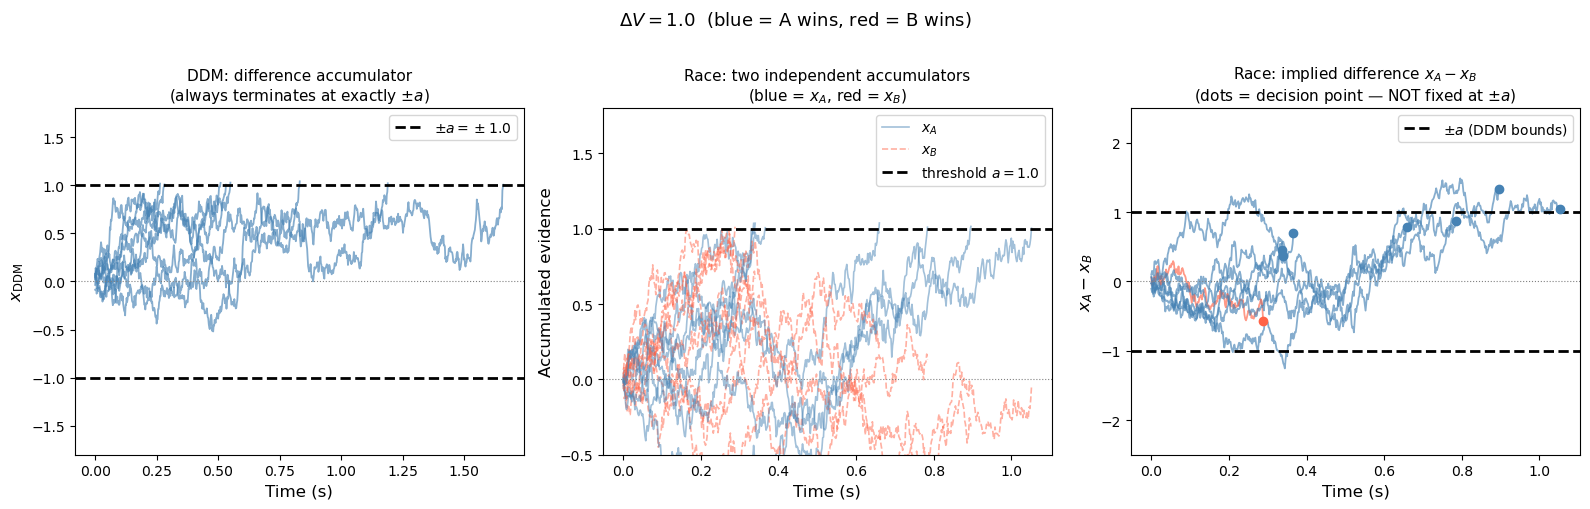

In [12]:
# ── 3-panel trace comparison: DDM | Race (x_A, x_B) | Race difference ─────────
# Same ΔV = 1.0 for all panels. Key point: the DDM accumulates the *difference*
# and always terminates at exactly ±a. The race model terminates when one
# accumulator hits +a — so the implied difference x_A − x_B at the moment of
# decision is NOT fixed; it depends on where the losing accumulator happens to be.

DV_TRACE = 1.0
mu_ddm   = ALPHA * DV_TRACE
va_t     = BASELINE + DV_TRACE / 2          # V_A for race
vb_t     = BASELINE - DV_TRACE / 2          # V_B for race
mu_A_t   = ALPHA * va_t
mu_B_t   = ALPHA * vb_t

np.random.seed(11)
n_traces  = 8
n_steps_t = int(3.0 / DT)
t_vec_t   = np.arange(n_steps_t) * DT

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for trial in range(n_traces):
    # ── DDM: single accumulator for the difference ──────────────────────────
    noise_ddm = SIGMA * np.sqrt(DT) * np.random.randn(n_steps_t)
    x_ddm     = np.cumsum(mu_ddm * DT + noise_ddm)
    hit_ddm   = np.where((x_ddm >= A) | (x_ddm <= -A))[0]
    t_end_ddm = hit_ddm[0] + 1 if len(hit_ddm) else n_steps_t
    col_ddm   = 'steelblue' if x_ddm[t_end_ddm - 1] >= 0 else 'tomato'
    axes[0].plot(t_vec_t[:t_end_ddm], x_ddm[:t_end_ddm],
                 color=col_ddm, alpha=0.65, linewidth=1.3)

    # ── Race: two independent accumulators ─────────────────────────────────
    noise_A = SIGMA * np.sqrt(DT) * np.random.randn(n_steps_t)
    noise_B = SIGMA * np.sqrt(DT) * np.random.randn(n_steps_t)
    x_A     = np.cumsum(mu_A_t * DT + noise_A)
    x_B     = np.cumsum(mu_B_t * DT + noise_B)

    hit_A   = np.where(x_A >= A)[0];  t_A = hit_A[0] if len(hit_A) else n_steps_t
    hit_B   = np.where(x_B >= A)[0];  t_B = hit_B[0] if len(hit_B) else n_steps_t
    t_end_r = min(t_A, t_B) + 1
    a_wins  = t_A <= t_B
    col_r   = 'steelblue' if a_wins else 'tomato'

    axes[1].plot(t_vec_t[:t_end_r], x_A[:t_end_r],
                 color='steelblue', alpha=0.5, linewidth=1.2,
                 label='$x_A$' if trial == 0 else '')
    axes[1].plot(t_vec_t[:t_end_r], x_B[:t_end_r],
                 color='tomato', alpha=0.5, linewidth=1.2, linestyle='--',
                 label='$x_B$' if trial == 0 else '')

    # ── Race difference: x_A − x_B ─────────────────────────────────────────
    diff    = x_A - x_B
    end_val = diff[t_end_r - 1]
    axes[2].plot(t_vec_t[:t_end_r], diff[:t_end_r],
                 color=col_r, alpha=0.65, linewidth=1.3)
    axes[2].plot(t_vec_t[t_end_r - 1], end_val,
                 'o', color=col_r, markersize=6, zorder=5)

# ── Formatting ──────────────────────────────────────────────────────────────
for ax in axes:
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Time (s)', fontsize=12)

axes[0].axhline( A, color='k', linewidth=2, linestyle='--', label=f'$\\pm a = \\pm{A}$')
axes[0].axhline(-A, color='k', linewidth=2, linestyle='--')
axes[0].set_ylabel('$x_{\\rm DDM}$', fontsize=12)
axes[0].set_title('DDM: difference accumulator\n(always terminates at exactly $\\pm a$)', fontsize=11)
axes[0].set_ylim([-1.8, 1.8])
axes[0].legend(fontsize=10)

axes[1].axhline(A, color='k', linewidth=2, linestyle='--', label=f'threshold $a={A}$')
axes[1].set_ylabel('Accumulated evidence', fontsize=12)
axes[1].set_title('Race: two independent accumulators\n(blue = $x_A$, red = $x_B$)', fontsize=11)
axes[1].set_ylim([-0.5, 1.8])
axes[1].legend(fontsize=10)

axes[2].axhline( A, color='k', linewidth=2, linestyle='--', label=f'$\\pm a$ (DDM bounds)')
axes[2].axhline(-A, color='k', linewidth=2, linestyle='--')
axes[2].set_ylabel('$x_A - x_B$', fontsize=12)
axes[2].set_title('Race: implied difference $x_A - x_B$\n(dots = decision point — NOT fixed at $\\pm a$)', fontsize=11)
axes[2].set_ylim([-2.5, 2.5])
axes[2].legend(fontsize=10)

fig.suptitle(f'$\\Delta V = {DV_TRACE}$  (blue = A wins, red = B wins)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

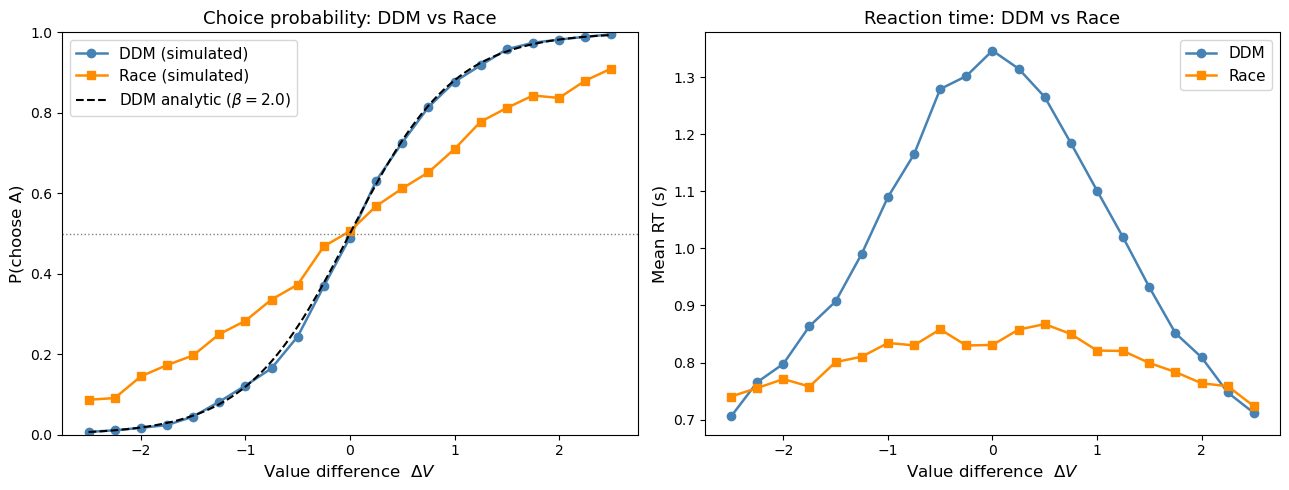

In [13]:
delta_vs_2 = np.linspace(-2.5, 2.5, 21)
n_sim = 1000

p_ddm_2, rt_ddm_2   = [], []
p_race_2, rt_race_2 = [], []

for i, dv in enumerate(delta_vs_2):
    # DDM
    ch_d, rt_d = simulate_ddm(dv, n_trials=n_sim, seed=i)
    p_ddm_2.append(ch_d.mean())
    rt_ddm_2.append(rt_d.mean())

    # Race: V_A = BASELINE + dv/2,  V_B = BASELINE − dv/2
    ch_r, rt_r = simulate_race([BASELINE + dv/2, BASELINE - dv/2],
                                n_trials=n_sim, seed=i + 1000)
    p_race_2.append((ch_r == 0).mean())   # P(A) = P(winner is option 0)
    rt_race_2.append(rt_r.mean())

# Analytic DDM sigmoid for reference
dv_fine2 = np.linspace(-2.5, 2.5, 300)
p_ddm_analytic = 1 / (1 + np.exp(-beta_theory * dv_fine2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── P(A) ──
ax = axes[0]
ax.plot(delta_vs_2, p_ddm_2,  'o-', color='steelblue',   markersize=6, linewidth=1.8, label='DDM (simulated)')
ax.plot(delta_vs_2, p_race_2, 's-', color='darkorange',   markersize=6, linewidth=1.8, label='Race (simulated)')
ax.plot(dv_fine2, p_ddm_analytic, 'k--', linewidth=1.5,
        label=f'DDM analytic ($\\beta={beta_theory:.1f}$)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Value difference  $\\Delta V$', fontsize=12)
ax.set_ylabel('P(choose A)', fontsize=12)
ax.set_title('Choice probability: DDM vs Race', fontsize=13)
ax.legend(fontsize=11); ax.set_ylim([0, 1])

# ── Mean RT ──
ax = axes[1]
ax.plot(delta_vs_2, rt_ddm_2,  'o-', color='steelblue',  markersize=6, linewidth=1.8, label='DDM')
ax.plot(delta_vs_2, rt_race_2, 's-', color='darkorange',  markersize=6, linewidth=1.8, label='Race')
ax.set_xlabel('Value difference  $\\Delta V$', fontsize=12)
ax.set_ylabel('Mean RT (s)', fontsize=12)
ax.set_title('Reaction time: DDM vs Race', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Both models produce a **sigmoid choice curve** and a **U-shaped RT function** — the qualitative predictions are the same. The race model's curve is shallower because the independent noises add ($\sigma_{\rm eff} = \sigma\sqrt{2}$), giving an effective $\beta_{\rm race} \approx a\alpha/\sigma^2 = 1.0$ instead of $2.0$.

The RT curves also differ subtly: the race model's minimum RT is lower (both accumulators race fast when their values are high and symmetric), whereas the DDM's RT depends only on the value *difference*.

---
### 6.2 — Three choices

Adding a third option is trivial: just add a third accumulator. There is no analytic extension of the DDM to three options, but the race model generalises immediately.

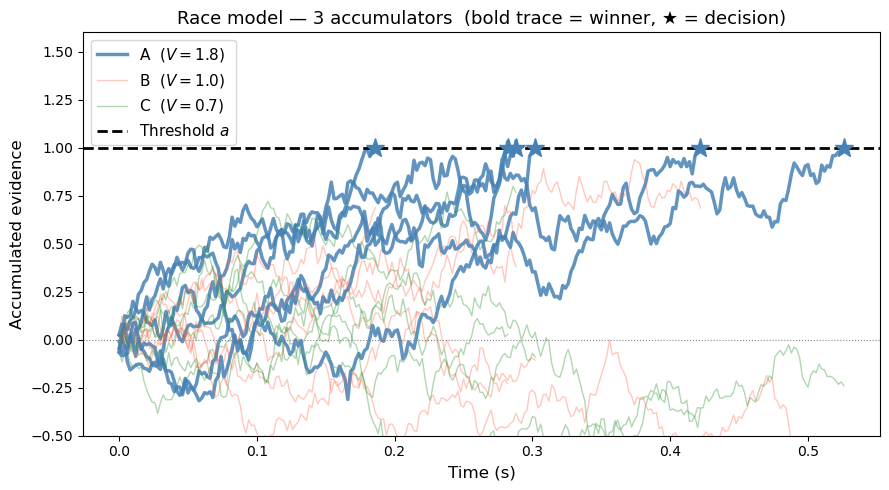

In [14]:
# ── Example trajectories: 3 accumulators ──────────────────────────────────────
V3 = np.array([BASELINE + 0.8, BASELINE, BASELINE - 0.3])   # A > B > C
opt_colors = ['steelblue', 'tomato', 'forestgreen']
opt_labels  = [f'A  ($V={V3[0]:.1f}$)', f'B  ($V={V3[1]:.1f}$)', f'C  ($V={V3[2]:.1f}$)']

np.random.seed(5)
n_traces  = 6
n_steps3  = int(4.0 / DT)
t3        = np.arange(n_steps3) * DT
mu3       = ALPHA * V3   # (3,)

fig, ax = plt.subplots(figsize=(9, 5))

for trial in range(n_traces):
    noise3 = SIGMA * np.sqrt(DT) * np.random.randn(3, n_steps3)
    x3     = np.cumsum(mu3[:, None] * DT + noise3, axis=1)    # (3, n_steps)

    hit3   = x3 >= A
    t_hit  = np.array([np.argmax(hit3[k]) if hit3[k].any() else n_steps3
                       for k in range(3)])
    winner = int(np.argmin(t_hit))
    t_end  = int(t_hit[winner])

    for k in range(3):
        lbl = opt_labels[k] if trial == 0 else None
        ax.plot(t3[:t_end + 1], x3[k, :t_end + 1],
                color=opt_colors[k],
                linewidth=2.5 if k == winner else 1.0,
                alpha=0.85 if k == winner else 0.35,
                label=lbl)
    ax.plot(t3[t_end], A, '*', color=opt_colors[winner], markersize=14, zorder=5)

ax.axhline(A, color='k', linewidth=2, linestyle='--', label='Threshold $a$')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accumulated evidence', fontsize=12)
ax.set_title('Race model — 3 accumulators  (bold trace = winner, ★ = decision)', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim([-0.5, 1.6])
plt.tight_layout()
plt.show()

---
### 6.3 — Three-option policy: Race model vs Softmax

We now vary $V_A$ while holding $V_B = V_C = \text{BASELINE}$, and compare the race model's choice probabilities to the softmax. We fit $\beta$ from the race model data so the comparison is on equal footing.

With default parameters ($\alpha=1$) the race model's effective $\beta \approx 1$, giving a shallow curve. To get a steeper, more realistic policy we raise $\alpha = 2$ — this doubles the drift and produces $\beta_{\rm race} \approx 2$, matching the DDM.

In [15]:
ALPHA_RACE = 2.0   # higher drift scaling → steeper choice curve (β_race ≈ a·α/σ² ≈ 2)

# ── Sweep V_A; V_B = V_C = BASELINE ──────────────────────────────────────────
va_sweep = np.linspace(BASELINE - 1.5, BASELINE + 1.5, 25)
n_sim3   = 2000

p_A3, p_B3, p_C3 = [], [], []
rt_A3 = []

for i, va in enumerate(va_sweep):
    ch, rt = simulate_race([va, BASELINE, BASELINE], alpha=ALPHA_RACE,
                           n_trials=n_sim3, seed=i + 3000)
    p_A3.append((ch == 0).mean())
    p_B3.append((ch == 1).mean())
    p_C3.append((ch == 2).mean())
    rt_A3.append(rt.mean())

p_A3, p_B3, p_C3 = map(np.array, [p_A3, p_B3, p_C3])

# ── Fit beta from the 3-option race model data ────────────────────────────────
all_ch3 = []
for i, va in enumerate(va_sweep):
    ch, _ = simulate_race([va, BASELINE, BASELINE], alpha=ALPHA_RACE,
                          n_trials=n_sim3, seed=i + 3000)
    all_ch3.append(ch)
all_ch3 = np.concatenate(all_ch3)

def neg_ll_softmax3(beta):
    ll = 0.0
    for i, va in enumerate(va_sweep):
        ch = all_ch3[i * n_sim3:(i + 1) * n_sim3]
        vals = np.array([va, BASELINE, BASELINE])
        logits_shifted = beta * (vals - vals.max())
        log_softmax = logits_shifted - np.log(np.sum(np.exp(logits_shifted)))
        ll += np.sum(log_softmax[ch])
    return -ll

res3 = minimize_scalar(neg_ll_softmax3, bounds=(0.01, 10.0), method='bounded')
beta_race3 = res3.x
beta_race_theory = A * ALPHA_RACE / SIGMA**2
print(f'Fitted softmax beta (3-option race):  {beta_race3:.3f}')
print(f'Expected (≈ a·alpha/sigma²):          {beta_race_theory:.3f}')

Fitted softmax beta (3-option race):  1.383
Expected (≈ a·alpha/sigma²):          2.000


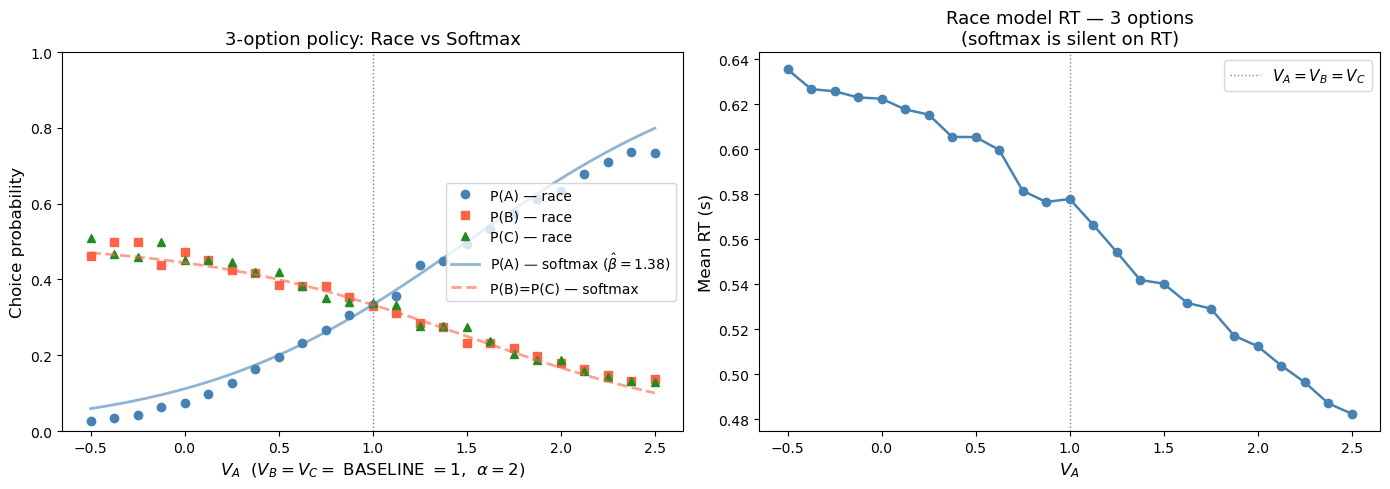


With alpha=2.0: fitted beta=1.383,  theoretical a·alpha/sigma²=2.000
At V_A=BASELINE: P(A)=0.333  P(B)=0.330  P(C)=0.338


In [16]:
# ── Softmax predictions with fitted beta ──────────────────────────────────────
va_fine = np.linspace(BASELINE - 1.5, BASELINE + 1.5, 300)

def softmax3(va, beta):
    vals = np.array([va, BASELINE, BASELINE])
    e    = np.exp(beta * (vals - vals.max()))
    return e / e.sum()

p_A_sm  = np.array([softmax3(va, beta_race3)[0] for va in va_fine])
p_BC_sm = np.array([softmax3(va, beta_race3)[1] for va in va_fine])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: choice probabilities ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(va_sweep, p_A3, 'o', color='steelblue',  markersize=6, label='P(A) — race')
ax.plot(va_sweep, p_B3, 's', color='tomato',      markersize=6, label='P(B) — race')
ax.plot(va_sweep, p_C3, '^', color='forestgreen', markersize=6, label='P(C) — race')
ax.plot(va_fine, p_A_sm,  '-',  color='steelblue', linewidth=2, alpha=0.6,
        label=f'P(A) — softmax ($\\hat{{\\beta}}={beta_race3:.2f}$)')
ax.plot(va_fine, p_BC_sm, '--', color='tomato',    linewidth=2, alpha=0.6,
        label='P(B)=P(C) — softmax')
ax.axvline(BASELINE, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('$V_A$  ($V_B = V_C = $ BASELINE $= 1$,  $\\alpha={:.0f}$)'.format(ALPHA_RACE), fontsize=12)
ax.set_ylabel('Choice probability', fontsize=12)
ax.set_title('3-option policy: Race vs Softmax', fontsize=13)
ax.legend(fontsize=10, loc='center right')
ax.set_ylim([0, 1])

# ── Right: mean RT ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(va_sweep, rt_A3, 'o-', color='steelblue', markersize=6, linewidth=1.8)
ax.axvline(BASELINE, color='gray', linestyle=':', linewidth=1, label='$V_A = V_B = V_C$')
ax.set_xlabel('$V_A$', fontsize=12)
ax.set_ylabel('Mean RT (s)', fontsize=12)
ax.set_title('Race model RT — 3 options\n(softmax is silent on RT)', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'\nWith alpha={ALPHA_RACE}: fitted beta={beta_race3:.3f},  '
      f'theoretical a·alpha/sigma²={beta_race_theory:.3f}')
print(f'At V_A=BASELINE: P(A)={p_A3[len(va_sweep)//2]:.3f}  '
      f'P(B)={p_B3[len(va_sweep)//2]:.3f}  P(C)={p_C3[len(va_sweep)//2]:.3f}')

**The race model closely approximates a softmax for 3 options**, with the same qualitative behaviour: P(A) rises as $V_A$ increases, and P(B) = P(C) because those two options are symmetric. The fitted $\beta$ is close to $a\alpha/\sigma^2 = 1.0$, as predicted.

**The RT panel shows something the softmax cannot:** when $V_A = V_B = V_C$ (all options equal), RT is at its maximum — the race is undecided and takes longer. As $V_A$ moves away from baseline in either direction, one accumulator gains a speed advantage and RT decreases.

| | DDM (2 options) | Race (2 options) | Race (K options) | Softmax |
|---|:---:|:---:|:---:|:---:|
| Choice probability | sigmoid | sigmoid-like | softmax-like | exact softmax |
| Reaction time | U-shaped | U-shaped | U-shaped | — |
| Scales to K options | ✗ | — | ✓ | ✓ |
| Mechanistic | ✓ | ✓ | ✓ | ✗ |